In [1]:
from gdt.core import data_path
from gdt.missions.fermi.gbm.tte import GbmTte
from gdt.core.binning.unbinned import bin_by_time
from scipy import stats
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from gdt.core.plot.lightcurve import Lightcurve
from gdt.missions.fermi.time import Time

In [2]:
dict = {"hi": "HELLO", "world": "WORLD"}
for i in dict:
    print(dict[i])

HELLO
WORLD


In [3]:
json_object = {}
trig_number = 1

In [4]:
try:
    json_object[str(trig_number)]["value"] = 4
    print("This")
except:
    json_object[str(trig_number)] = {}
    json_object[str(trig_number)]["value"] = 4
    print("That")

That


In [5]:
H_naught_mpc = 67.3
Lambda_m = 0.315
Lambda_G = 0.685
Lambda_k = 0.685
conversion= 3.08567758128*10**19
H_naught = H_naught_mpc/conversion
E = [29.802994,22.73866,77.106875,39.881582,29.91478,27.428805,19.459947]
z = [1.368,2.67,0.34,1.822,0.903,4.35,2.1062]
H_naught

2.181044461945458e-18

In [6]:
H_naught_mpc_err = 1.2
Lambda_m_err = 0.0165
Lambda_G_err = 0.0165
H_naught_err = H_naught_mpc_err/conversion
E_err = [0.15*value for value in E]
z_err = [0,0.37,0.0002,0,0.003,0.15,0.0001]
H_naught_err

3.888935147599628e-20

In [7]:
def f(t):
    num = np.float128((1+t))
    den = np.float128((Lambda_m*(1+t)**3)+Lambda_G)
    return num/(np.sqrt(den))

In [8]:
def calc(i):
    K_int = sp.integrate.quad(f, 0, z[i])
    K_pre = (1/H_naught)*(E[i]/(1+z[i]))
    K = K_pre*K_int[0]
    return K

In [9]:
def calc_err(i):
    K_int_seq = sp.integrate.quad(f, 0, z[i])
    K_int = K_int_seq[0]
    num = (1+z[i])
    den = (Lambda_m*(1+z[i])**3)+Lambda_G
    den_two_err = np.sqrt((Lambda_m_err)**2+(3*z_err[i])**2)
    den_err = 0.5 * np.sqrt((Lambda_G_err)**2+(den_two_err)**2)
    K_int_err = K_int*np.sqrt((z_err[i]/num)**2+(den_err/den)**2)

    K_err = np.sqrt((H_naught_err/H_naught)**2+(E_err[i]/E[i])**2+(z_err[i]/z[i])**2+(K_int_err/K_int)**2)
    return K_err

In [10]:
calc(0)

8.730618793098522e+18

In [11]:
calc_tot = []
for i in range(0, len(z)):
    calc_tot.append(calc(i))
calc_tot

[8.730618793098522e+18,
 7.955340195287713e+18,
 9.577958936563306e+18,
 1.287192976969158e+19,
 7.213075528009924e+18,
 9.868497718671809e+18,
 6.517805078243891e+18]

In [12]:
calc_tot_err = []
for i in range(0, len(z_err)):
    calc_tot_err.append(calc(i)*calc_err(i))
calc_tot_err

[np.float64(1.318978812861322e+18),
 np.float64(1.8375249805538442e+18),
 np.float64(1.4488929975189343e+18),
 np.float64(1.944479091840735e+18),
 np.float64(1.0903590629870422e+18),
 np.float64(1.5545404417411203e+18),
 np.float64(9.845826171977793e+17)]

In [13]:
t_obs = [4.145472556,0.1671283382,6.223762665,25.70176791,0.4352222789,7.188954956,7.00741324]

In [20]:
x_data = calc_tot
y_data = t_obs
lin = stats.linregress(x_data, y_data)
[lin.slope, lin.stderr]

[np.float64(3.453287839992481e-18), np.float64(9.91742500362842e-19)]

In [15]:
#def p(x):
#    return lin.slope*x+lin.intercept

In [16]:
lin.slope*np.float64(1.4e+19)+lin.intercept

np.float64(24.66416244440191)

In [17]:
calc_tot+[1.4e+19]

[8.730618793098522e+18,
 7.955340195287713e+18,
 9.577958936563306e+18,
 1.287192976969158e+19,
 7.213075528009924e+18,
 9.868497718671809e+18,
 6.517805078243891e+18,
 1.4e+19]

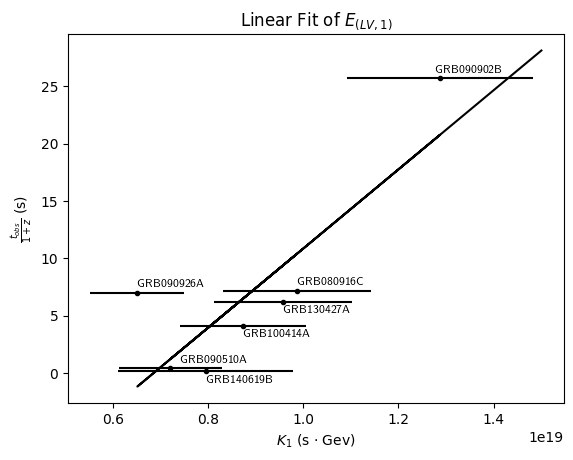

In [18]:
fig, ax = plt.subplots()
plt.rcParams['text.usetex'] = True

ax.errorbar(calc_tot,t_obs,xerr=calc_tot_err,fmt="k.")
#plt.xlim(0,10e+18)
z = np.polyfit(calc_tot, t_obs, 1)
p = np.poly1d(z)
ax.plot(calc_tot+[1.5e+19], p(calc_tot+[1.5e+19]),"k")

labels = [r'GRB100414A', r'GRB140619B', r'GRB130427A', r'GRB090902B', r'GRB090510A', r'GRB080916C', r'GRB090926A']
hi_lo = [-1,-1,-1,0.5,0.5,0.5,0.5]
sides = [0,0,0,-1e+17,2e+17,0,0]

for i in range(0, len(calc_tot)):
    ax.text(calc_tot[i]+sides[i], t_obs[i]+hi_lo[i], labels[i], fontsize=8)

ax.set_title(r'Linear Fit of $E_{(LV,1)}$')
plt.xlabel(r'$K_1$ (s $\cdot$ Gev)')
plt.ylabel(r'$\frac{t_{obs}}{1+z}$ (s)')

    
plt.savefig("lin_fit.png")